In [1]:
import os
import numpy as np
import tensorflow as tf
import sklearn
import cv2

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Sisanya gunakan dari keras standalone
from keras.models import Model
from keras.applications import EfficientNetB2
from keras.applications.efficientnet import preprocess_input
from keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from keras.optimizers import Adam


In [2]:
os.add_dll_directory("C:/Program Files/NVIDIA GPU Computing Toolkit/CUDA/v11.2/bin")
os.add_dll_directory("C:/Program Files/NVIDIA GPU Computing Toolkit/CUDA/v11.2/libnvvp")

<AddedDllDirectory('C:/Program Files/NVIDIA GPU Computing Toolkit/CUDA/v11.2/libnvvp')>

In [3]:
import tensorflow as tf
print(tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Menginstal paket Kaggle
!pip install kaggle -q

# Mengunduh dataset baru
!kaggle datasets download -d asdasdasasdas/garbage-classification

Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
garbage-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
# Mengekstrak file zip yang diunduh
import zipfile
with zipfile.ZipFile('garbage-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('garbage_data')

In [6]:
# Step 1: Prepare Dataset
dataset_path = "garbage_data/Garbage classification/Garbage classification"
classes = os.listdir(dataset_path)
print("Classes:", classes)

# Prepare the dataset paths and labels
image_paths, labels = [], []
for label, class_name in enumerate(classes):
    class_dir = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_dir):
        image_paths.append(os.path.join(class_dir, img_name))
        labels.append(label)

# Create a DataFrame
import pandas as pd
data = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

# Split dataset
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data['label'], random_state=42)

# Image preprocessing and augmentation
IMG_SIZE = 224
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img

def augment_image(img):
    # Example: Augmentations (flip, rotation)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.rot90(img)
    return img

# Step 2: Data Generators
def data_generator(data, batch_size=32, augment=False):
    while True:
        batch_data = data.sample(batch_size)
        batch_images, batch_labels = [], []
        for _, row in batch_data.iterrows():
            img = preprocess_image(row['image_path'])
            label = row['label']
            if augment:
                img = augment_image(img)
            batch_images.append(img)
            batch_labels.append(label)
        yield np.array(batch_images), np.array(batch_labels)

train_gen = data_generator(train_df, batch_size=32, augment=True)
test_gen = data_generator(test_df, batch_size=32)

# Step 3: Build Classification Model with EfficientNet-B2
base_model = EfficientNetB2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)
output = Dense(len(classes), activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=output)

# Freeze the base model initially
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Step 4: Train the Model
history = model.fit(train_gen,
                    steps_per_epoch=len(train_df)//32,
                    validation_data=test_gen,
                    validation_steps=len(test_df)//32,
                    epochs=10)

# Step 5: Evaluate the Model
test_images, test_labels = next(test_gen)
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Epoch 1/10
63/63 [==============================] - 48s 584ms/step - loss: 1.1039 - accuracy: 0.6076 - val_loss: 0.7000 - val_accuracy: 0.7958
Epoch 2/10
63/63 [==============================] - 26s 415ms/step - loss: 0.6245 - accuracy: 0.7976 - val_loss: 0.5488 - val_accuracy: 0.8271
Epoch 3/10
63/63 [==============================] - 24s 380ms/step - loss: 0.4921 - accuracy: 0.8393 - val_loss: 0.4422 - val_accuracy: 0.8583
Epoch 4/10
63/63 [==============================] - 22s 354ms/step - loss: 0.4504 - accuracy: 0.8447 - val_loss: 0.4068 - val_accuracy: 0.8646
Epoch 5/10
63/63 [==============================] - 22s 351ms/step - loss: 0.3991 - accuracy: 0.8586 - val_loss: 0.4158 - val_accuracy: 0.8667
Epoch 6/10
63/63 [==============================] - 24s 385ms/step - loss: 0.3920 - accuracy: 0.8676 - val_loss: 0.3523 - val_accuracy: 0.8854
Epoch 7/10
63/63 [==============================] - 22s 351ms/step - los

In [7]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

# Ambil label unik
unique_labels = np.unique(test_labels)
label_names = [classes[i] for i in unique_labels]

# Classification Report
print("Classification Report:")
print(classification_report(test_labels, predicted_labels, target_names=label_names))

# Metric
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, predicted_labels, average='weighted')
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")


Classification Report:
              precision    recall  f1-score   support

   cardboard       1.00      1.00      1.00         4
       glass       0.86      1.00      0.92         6
       metal       0.75      0.75      0.75         4
       paper       1.00      1.00      1.00         8
     plastic       0.83      0.71      0.77         7
       trash       1.00      1.00      1.00         3

    accuracy                           0.91        32
   macro avg       0.91      0.91      0.91        32
weighted avg       0.91      0.91      0.90        32

Precision: 0.91, Recall: 0.91, F1-Score: 0.90


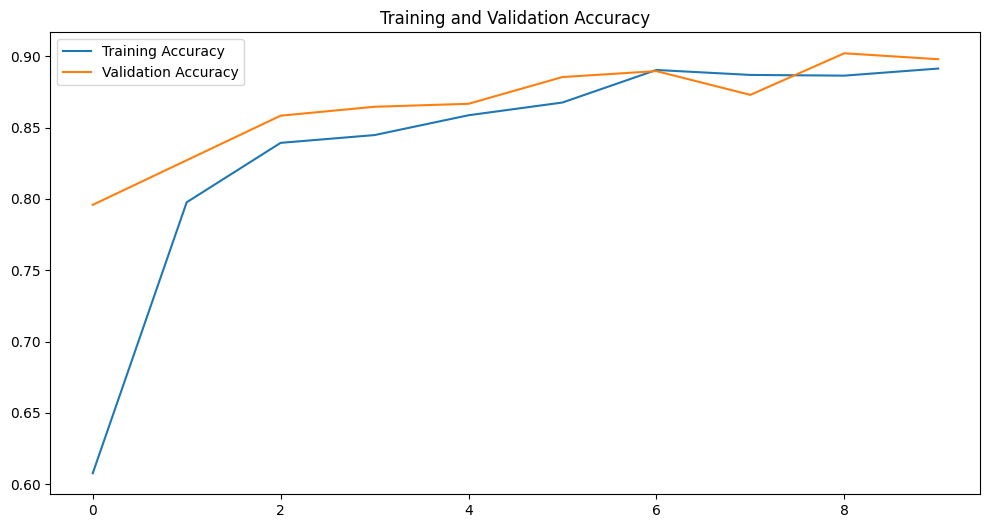

In [8]:
# Plot Training Accuracy and Loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [9]:
# Hyperparameter Adjustments
BATCH_SIZE = 64
IMG_SIZE = 224
EPOCHS = 15
INITIAL_LR = 0.0001
FINE_TUNE_LAYERS = 20
FINE_TUNE_LR = 0.0001
DROPOUT_RATE = 0.3

# Enhanced Augmentation: flip, rotate, brightness, contrast
def augment_image(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.rot90(img)  # <-- rotate
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    return img

# Data Generator Function
def data_generator(data, batch_size=BATCH_SIZE, augment=False):
    while True:
        batch_data = data.sample(batch_size)
        batch_images, batch_labels = [], []
        for _, row in batch_data.iterrows():
            img = preprocess_image(row['image_path'])
            if augment:
                img = augment_image(img)
            batch_images.append(img)
            batch_labels.append(row['label'])
        yield np.array(batch_images), np.array(batch_labels)

train_gen = data_generator(train_df, batch_size=BATCH_SIZE, augment=True)
test_gen = data_generator(test_df, batch_size=BATCH_SIZE)

# Load Pretrained EfficientNetB2 Model
base_model = EfficientNetB2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(DROPOUT_RATE)(x)
output = Dense(len(classes), activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=output)

# Freeze Base Model Layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the Model
model.compile(optimizer=Adam(learning_rate=INITIAL_LR),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=2, min_lr=1e-6)
]

# Train the Model
history = model.fit(train_gen,
                    steps_per_epoch=len(train_df) // BATCH_SIZE,
                    validation_data=test_gen,
                    validation_steps=len(test_df) // BATCH_SIZE,
                    epochs=EPOCHS,
                    callbacks=callbacks)

# Fine-tuning: unfreeze last N layers
for layer in base_model.layers[-FINE_TUNE_LAYERS:]:
    layer.trainable = True

# Recompile with Fine-Tune Learning Rate
model.compile(optimizer=Adam(learning_rate=FINE_TUNE_LR),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Fine-Tune the Model
history_fine = model.fit(train_gen,
                         steps_per_epoch=len(train_df) // BATCH_SIZE,
                         validation_data=test_gen,
                         validation_steps=len(test_df) // BATCH_SIZE,
                         epochs=5,
                         callbacks=callbacks)

# Evaluate the Model
test_images, test_labels = next(test_gen)
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)


Epoch 1/15
31/31 [==============================] - 42s 1s/step - loss: 1.7949 - accuracy: 0.2450 - val_loss: 1.6530 - val_accuracy: 0.3460 - lr: 1.0000e-04
Epoch 2/15
31/31 [==============================] - 27s 890ms/step - loss: 1.6190 - accuracy: 0.3392 - val_loss: 1.5108 - val_accuracy: 0.4464 - lr: 1.0000e-04
Epoch 3/15
31/31 [==============================] - 26s 864ms/step - loss: 1.4579 - accuracy: 0.4713 - val_loss: 1.3721 - val_accuracy: 0.5513 - lr: 1.0000e-04
Epoch 4/15
31/31 [==============================] - 28s 908ms/step - loss: 1.3032 - accuracy: 0.5509 - val_loss: 1.2373 - val_accuracy: 0.6205 - lr: 1.0000e-04
Epoch 5/15
31/31 [==============================] - 29s 964ms/step - loss: 1.2219 - accuracy: 0.5887 - val_loss: 1.1441 - val_accuracy: 0.6496 - lr: 1.0000e-04
Epoch 6/15
31/31 [==============================] - 27s 889ms/step - loss: 1.1167 - accuracy: 0.6547 - val_loss: 1.1066 - val_accuracy: 0.6875 - lr: 1.0000e-04
Epoch 7/15
31/31 [=========================

In [10]:
# Classification Report
print("Classification Report:")
print(classification_report(test_labels, predicted_labels, target_names=classes))

Classification Report:
              precision    recall  f1-score   support

   cardboard       1.00      0.93      0.97        15
       glass       1.00      1.00      1.00        12
       metal       0.86      0.92      0.89        13
       paper       0.90      0.75      0.82        12
     plastic       0.75      1.00      0.86         9
       trash       0.50      0.33      0.40         3

    accuracy                           0.89        64
   macro avg       0.83      0.82      0.82        64
weighted avg       0.89      0.89      0.89        64



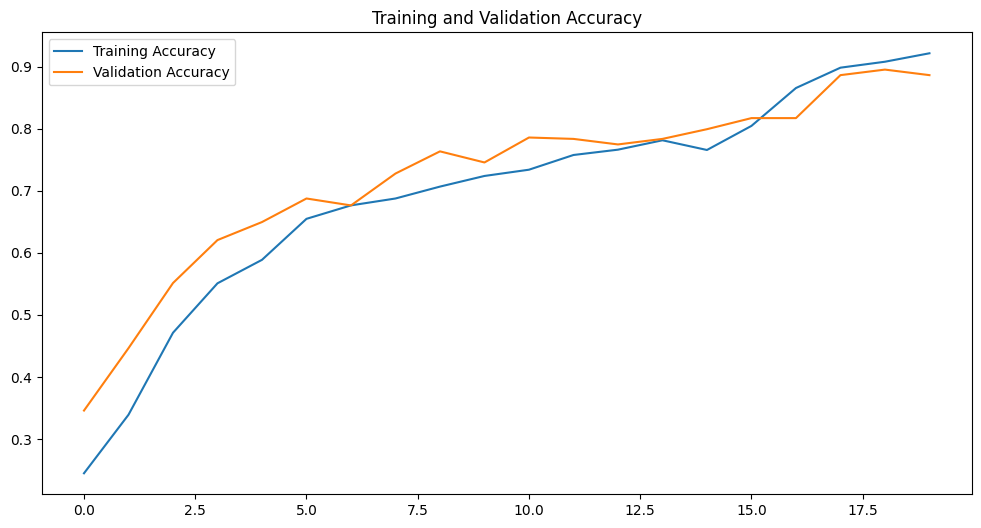

In [11]:

# Plot Training and Validation Metrics
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

2/2 [==============================] - 0s 130ms/step


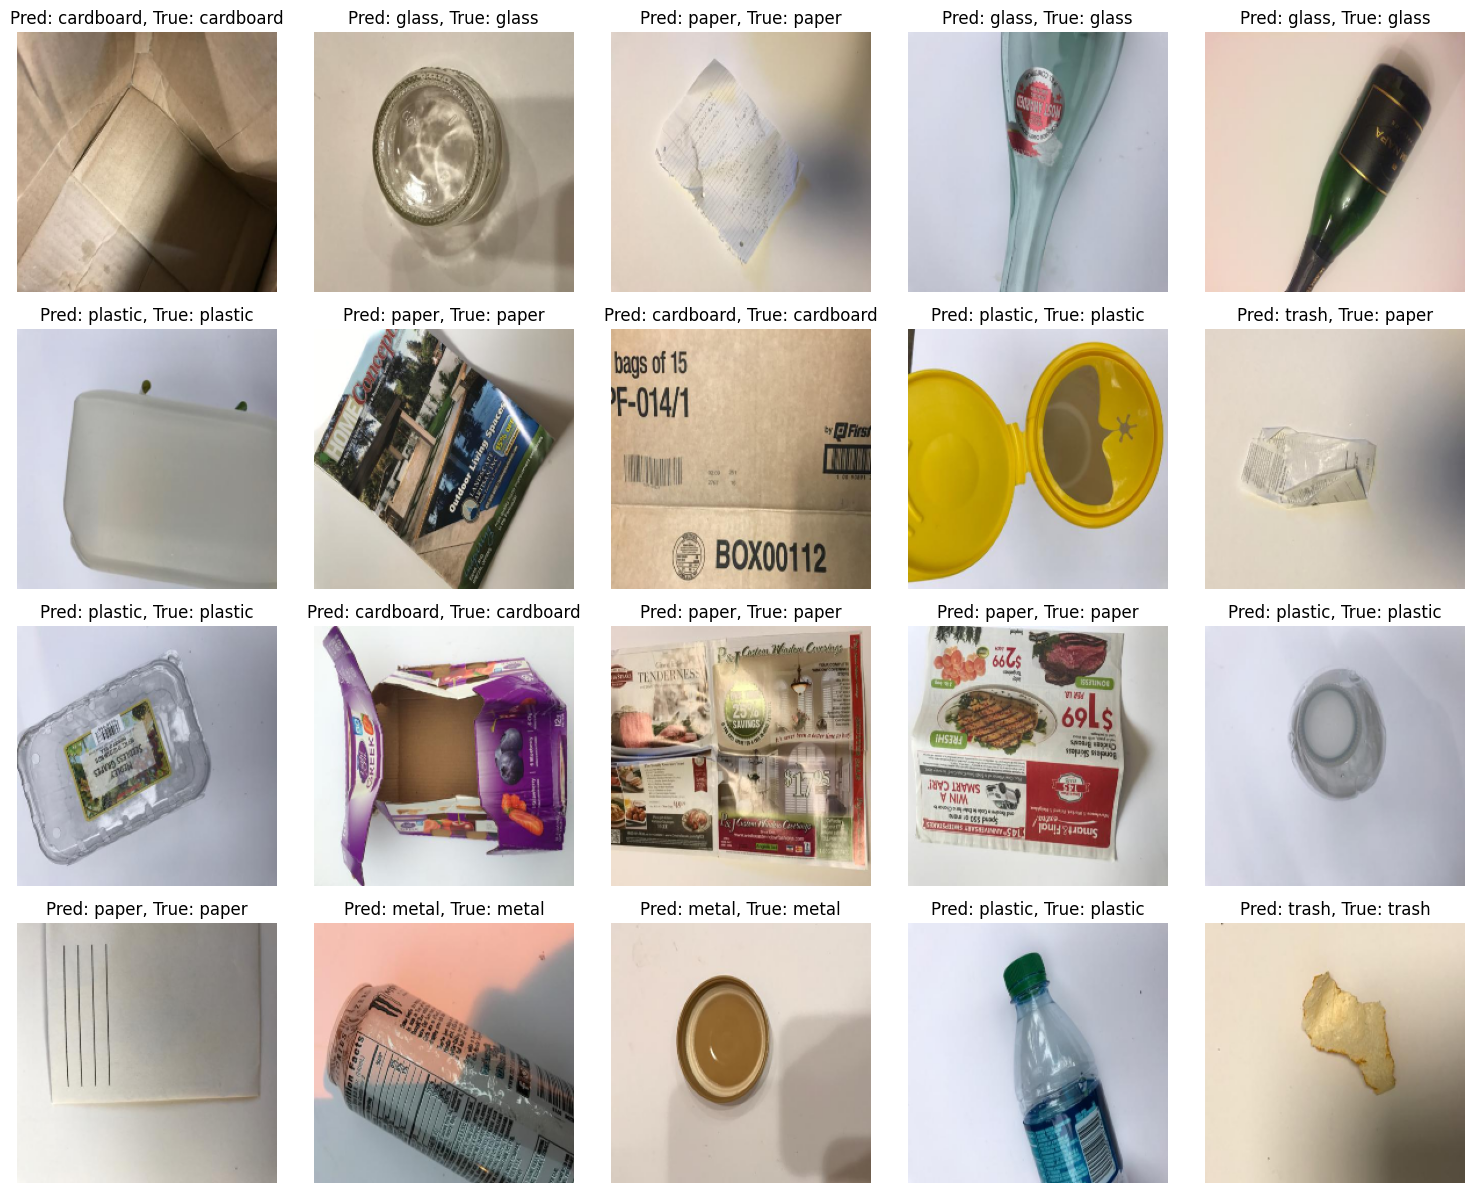

In [12]:
import matplotlib.pyplot as plt

# Visualize Predictions
def visualize_predictions(test_images, test_labels, predicted_labels, class_names, num_images=20):
    plt.figure(figsize=(15, 15))
    for i in range(num_images):
        ax = plt.subplot(5, 5, i + 1)
        img = test_images[i].astype("uint8")
        true_label = class_names[test_labels[i]]
        pred_label = class_names[predicted_labels[i]]
        plt.imshow(img)
        plt.title(f"Pred: {pred_label}, True: {true_label}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Use the first batch of test images
test_images, test_labels = next(test_gen)
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

# Class Names (based on dataset folders)
class_names = classes

# Visualize
visualize_predictions(test_images, test_labels, predicted_labels, class_names, num_images=20)


In [19]:
# 1. Simpan model
# model.save("best_model_trial1.keras")

# 2. Simpan bobot (optional)
model.save_weights("best_model_weights_trial1.h5")

# 3. Simpan report sebagai JSON
from sklearn.metrics import classification_report
import json

report = classification_report(test_labels, predicted_labels, output_dict=True)
with open("eval_report_trial1.json", "w") as f:
    json.dump(report, f, indent=4, default=str)  # <--- tambahkan default=str


In [ ]:
# model.summary()

In [ ]:
# from tensorflow.keras.utils import plot_model

# # Visualisasi struktur model
# plot_model(model, to_file='efficientnet_structure.png', show_shapes=True, show_layer_names=True)

In [ ]:
# # 2. Analisis Visualisasi Layer
# # Pilih beberapa layer dari EfficientNet untuk divisualisasikan
# layer_names = [layer.name for layer in base_model.layers if 'conv' in layer.name or 'pool' in layer.name]
# layer_outputs = [layer.output for layer in base_model.layers if 'conv' in layer.name or 'pool' in layer.name]

# # Model baru untuk visualisasi layer
# visualization_model = Model(inputs=base_model.input, outputs=layer_outputs)


In [ ]:
# # Pilih satu gambar dari dataset uji untuk divisualisasikan
# sample_image = preprocess_image(test_df['image_path'].iloc[0])
# sample_image = np.expand_dims(sample_image, axis=0)  # Tambahkan dimensi batch

# # Dapatkan output dari beberapa layer
# feature_maps = visualization_model.predict(sample_image)

# # Visualisasi beberapa feature maps
# for layer_name, feature_map in zip(layer_names, feature_maps):
#     if len(feature_map.shape) == 4:  # Jika feature map berbentuk (batch, height, width, channels)
#         num_channels = feature_map.shape[-1]
#         size = feature_map.shape[1]

#         plt.figure(figsize=(15, 15))
#         plt.suptitle(f"Feature Maps from Layer: {layer_name}")

#         # Plot beberapa channel pertama
#         for i in range(min(6, num_channels)):  # Batasi ke 6 channel pertama
#             plt.subplot(1, 6, i + 1)
#             plt.imshow(feature_map[0, :, :, i], cmap='viridis')
#             plt.axis('off')
#         plt.tight_layout()
#         plt.show()
